In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print("TensorFlow version :", tf.__version__)
print("Keras version :", keras.__version__)

TensorFlow version : 2.21.0
Keras version : 3.15.0


In [2]:
from pathlib import Path

In [5]:
# Configuration des chemins
import os
DATA_DIR = DATA_DIR = Path("../data/raw/images")

# Extensions d'images valides
EXTENSIONS_VALIDES = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}

# Vérification des classes disponibles
classes = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])

print(f"Nombre de classes : {len(classes)}")
print(f"Classes détectées : {classes}")

# Comptage des images par classe
print("\nNombre d'images par classe :")
total = 0
for classe in classes:
    chemin = os.path.join(DATA_DIR, classe)
    nb_images = len([
        f for f in os.listdir(chemin)
        if os.path.splitext(f)[1] in EXTENSIONS_VALIDES
    ])
    total += nb_images
    print(f"  {classe} : {nb_images} images")

print(f"\nTotal : {total} images")

Nombre de classes : 6
Classes détectées : ['Kedjenou', 'alloco', 'foutou', 'mafe', 'thieboudiene', 'yassa-poulet']

Nombre d'images par classe :
  Kedjenou : 100 images
  alloco : 100 images
  foutou : 100 images
  mafe : 100 images
  thieboudiene : 100 images
  yassa-poulet : 100 images

Total : 600 images


In [6]:
# Chargement des données avec Keras
IMG_SIZE   = (224, 224)  # Taille requise par EfficientNet-B0
BATCH_SIZE = 32          # Nombre d'images traitées à la fois
SEED       = 42          # Pour avoir des résultats reproductibles

# 80% des images → entraînement
train_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# 20% des images → validation
val_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print(f"Classes : {class_names}")
print(f"Images d'entraînement : {len(train_ds) * BATCH_SIZE}")
print(f"Images de validation  : {len(val_ds) * BATCH_SIZE}")

Found 600 files belonging to 6 classes.
Using 480 files for training.
Found 600 files belonging to 6 classes.
Using 120 files for validation.
Classes : ['Kedjenou', 'alloco', 'foutou', 'mafe', 'thieboudiene', 'yassa-poulet']
Images d'entraînement : 480
Images de validation  : 128


In [8]:
#  Augmentation légère (appliquée uniquement au train)
from tensorflow.keras import layers, models
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [9]:
# construction du modèle ResNet
base_model = tf.keras.applications.ResNet50(
    include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,)
)
base_model.trainable = False  # backbone gelé pour la phase 1
 
inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.resnet50.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
 
model = models.Model(inputs, outputs, name="ResNet50")
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 28s 0us/step


Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 6)         │     12,294 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,600,006 (90.03 MB)

 Trainable params: 12,294 (48.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [15]:
 # PHASE 1 : entraînement de la tête (backbone gelé)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
 
# Callbacks pour optimiser l'entraînement
callbacks = [
    # S'arrête si la validation ne s'améliore plus après 5 epochs
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    # Réduit le learning rate si stagnation
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    )
]
 
print("\n=== Phase 1 : entraînement de la tête ===")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)
print("\nEntraînement terminé !")


=== Phase 1 : entraînement de la tête ===
Epoch 1/20


15/15 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.2396 - loss: 2.0192 - val_accuracy: 0.4333 - val_loss: 1.3221 - learning_rate: 0.0010
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 56s 4s/step - accuracy: 0.5583 - loss: 1.1646 - val_accuracy: 0.7000 - val_loss: 0.8663 - learning_rate: 0.0010
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - accuracy: 0.6562 - loss: 0.8887 - val_accuracy: 0.7250 - val_loss: 0.7385 - learning_rate: 0.0010
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 57s 4s/step - accuracy: 0.7500 - loss: 0.7145 - val_accuracy: 0.7667 - val_loss: 0.6792 - learning_rate: 0.0010
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 58s 4s/step - accuracy: 0.8208 - loss: 0.5906 - val_accuracy: 0.7417 - val_loss: 0.6318 - learning_rate: 0.0010
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 73s 5s/step - accuracy: 0.8104 - loss: 0.5503 - val_accuracy: 0.7917 - val_loss: 0.5750 - learning_rate: 0.0010
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 83s 6s/step - accuracy: 0.8500 - loss: 0.4773 - val_accuracy: 0.7500 - va

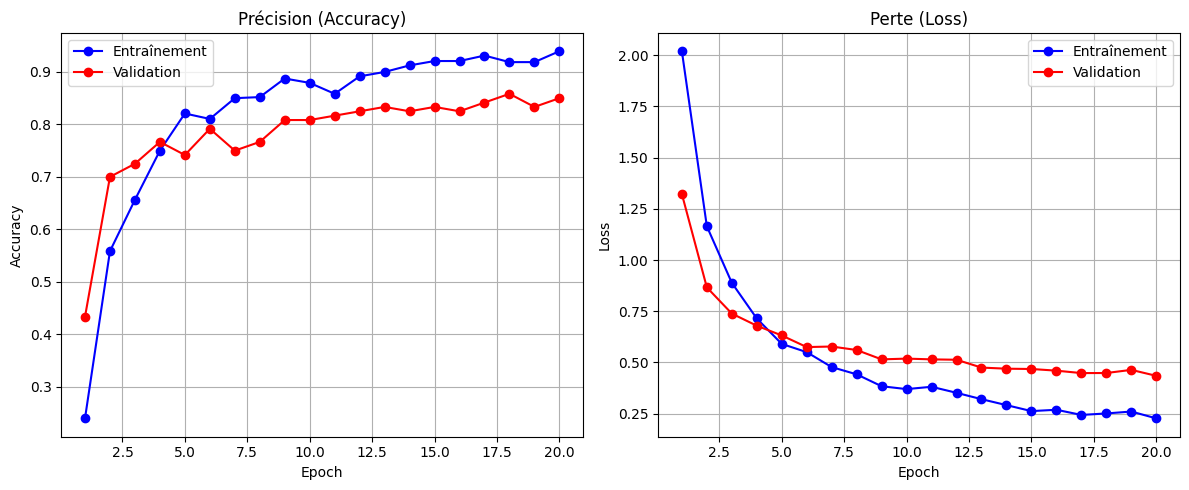

Courbes sauvegardées !


In [16]:
# Visualisation des courbes d'entraînement

import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Courbe Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, acc,  "b-o", label="Entraînement")
plt.plot(epochs, val_acc, "r-o", label="Validation")
plt.title("Précision (Accuracy)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Courbe Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss,     "b-o", label="Entraînement")
plt.plot(epochs, val_loss, "r-o", label="Validation")
plt.title("Perte (Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig("courbes_entrainement_resnet.png", dpi=150)
plt.tight_layout()
plt.show()
print("Courbes sauvegardées !")

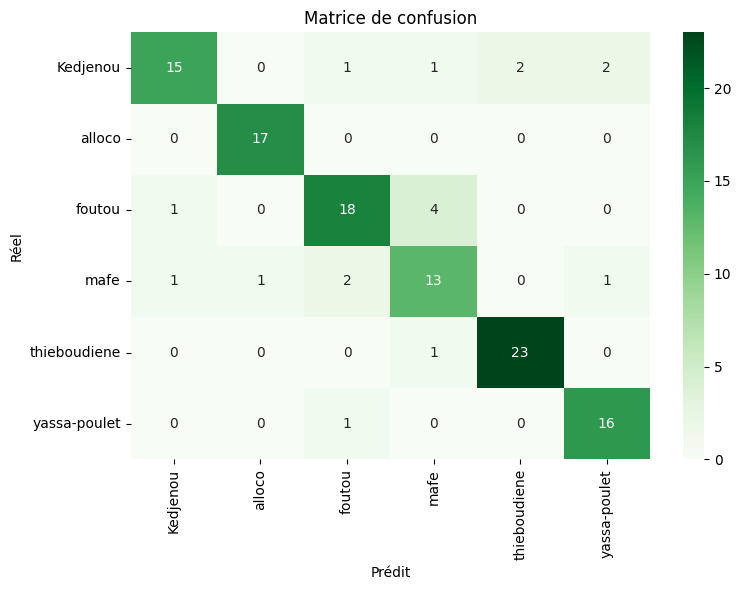


Rapport détaillé :
              precision    recall  f1-score   support

    Kedjenou       0.88      0.71      0.79        21
      alloco       0.94      1.00      0.97        17
      foutou       0.82      0.78      0.80        23
        mafe       0.68      0.72      0.70        18
thieboudiene       0.92      0.96      0.94        24
yassa-poulet       0.84      0.94      0.89        17

    accuracy                           0.85       120
   macro avg       0.85      0.85      0.85       120
weighted avg       0.85      0.85      0.85       120



In [18]:
# Matrice de confusion
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Prédictions sur la validation
y_pred = []
y_true = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Greens")
plt.title("Matrice de confusion")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.savefig("matrice_confusion_restnet.png", dpi=150)
plt.show()

print("\nRapport détaillé :")
print(classification_report(y_true, y_pred, target_names=class_names))

In [19]:
# Sauvegarde du modèle
import os

# Créer le dossier models s'il n'existe pas
os.makedirs("models", exist_ok=True)

# Sauvegarder le modèle au format Keras
model.save("models/restnet_phase1.keras")

print("Modèle sauvegardé dans models/resnet_phase1.keras ✅")
print(f"Précision finale : {max(history.history['val_accuracy']):.2%}")

Modèle sauvegardé dans models/resnet_phase1.keras ✅
Précision finale : 85.83%
